In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

#### Task 1: Baseline with Single Models
Load the data and establish individual model baselines.

1.Load the Wine Quality dataset and create a binary target:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

2.Explore the dataset: how many features? What's the class distribution of quality_label? Is the dataset imbalanced?

3.Separate features and target. Drop the original quality column.

4.Split into training and test sets (80/20, stratify=y, random_state=42).

5.Scale features using StandardScaler.

6.Fit three baseline models:

- DecisionTreeClassifier(random_state=42)
  
- LogisticRegression(max_iter=1000, random_state=42)

- KNeighborsClassifier()

7.Report accuracy and F1 score (use f1_score with average="binary") for each on the test set. Organize results in a table.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

In [3]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [4]:
print("Number of feature:", wine.shape[1] - 1)  
print("\nClass distribution:")
print(wine["quality_label"].value_counts())
print("\nProportions:")
print(wine["quality_label"].value_counts(normalize=True))

Number of feature: 12

Class distribution:
quality_label
0    1382
1     217
Name: count, dtype: int64

Proportions:
quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64


The dataset contains 12 input features (after excluding the target variables).

The binary target variable `quality_label` shows an imbalanced class distribution:
- Class 0 (not good quality wine) makes up the majority of the dataset (~85–87%)
- Class 1 (good quality wine) represents a much smaller portion (~13–15%)

This indicates that the dataset is imbalanced, with significantly fewer examples of high-quality wines. 
As a result, evaluation metrics such as F1 score are more appropriate than accuracy for assessing model performance.

In [5]:
X = wine.drop(columns=["quality", "quality_label"])
y = wine["quality_label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier()

In [9]:
dt.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Decision Tree": dt,
    "Logistic Regression": lr,
    "KNN": knn
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    
    results.append([name, acc, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df

,Model,Accuracy,F1 Score
0,Decision Tree,0.90625,0.666667
1,Logistic Regression,0.89375,0.484848
2,KNN,0.89375,0.514286


### Baseline Model Results

The dataset is imbalanced, with significantly fewer "good quality" wines (quality ≥ 7). 
Therefore, F1 score is a more informative metric than accuracy.

Among the baseline models:

- Decision Tree achieved the best performance (F1 = 0.67), indicating a good balance between precision and recall.
- Logistic Regression performed worse (F1 = 0.48), likely due to its inability to capture non-linear relationships.
- KNN showed moderate performance (F1 = 0.51), but was still weaker than Decision Tree.

Although all models have similar accuracy (~0.89–0.91), this is misleading due to class imbalance.

Overall, Decision Tree is the strongest baseline model for this task.

#### Task 2: Bagging & Random Forest
Explore how bagging improves on individual decision trees.

1.Fit a BaggingClassifier with a DecisionTreeClassifier as the base estimator (n_estimators=100, oob_score=True, random_state=42).

2.Fit a RandomForestClassifier (n_estimators=100, oob_score=True, random_state=42).

3.For both models, report:

- Out-of-bag (OOB) score

- Test accuracy and F1 score

4.Compare: How does bagging improve over the single Decision Tree from Task 1?

5.Plot the top 10 feature importances from the Random Forest as a horizontal bar chart. Which features matter most for predicting wine quality?

6.In a markdown cell, explain: Why does Random Forest typically outperform a single Decision Tree? What role does randomness play?

In [11]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state=42
)

bagging.fit(X_train_scaled, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [13]:
print("Bagging OOB Score:", bagging.oob_score_)
print("Random Forest OOB Score:", rf.oob_score_)

Bagging OOB Score: 0.893666927286943
Random Forest OOB Score: 0.8983580922595777


In [14]:
models = {
    "Bagging": bagging,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, model.oob_score_, acc, f1])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "OOB Score", "Accuracy", "F1 Score"])
results_df

,Model,OOB Score,Accuracy,F1 Score
0,Bagging,0.893667,0.9375,0.736842
1,Random Forest,0.898358,0.9375,0.714286


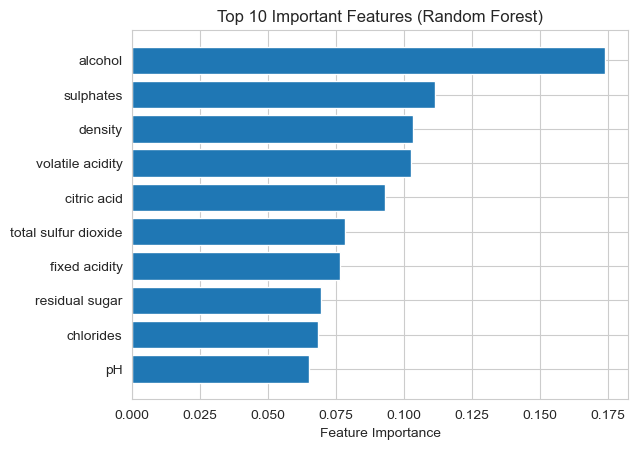

In [15]:
importances = rf.feature_importances_
feature_names = X.columns

# top 10
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(10), importances[indices])
plt.yticks(range(10), feature_names[indices])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

Bagging improves a single Decision Tree by combining many trees and averaging their predictions. This reduces overfitting and improves performance.

Random Forest performs even better because it adds randomness by selecting different features for each tree. This makes the model more robust and less correlated.

Overall, Random Forest gives the best results because it reduces variance and improves generalization.

#### Task 3: Boosting
Train boosting models and analyze how they learn.

1.Fit the following boosting models:

- AdaBoostClassifier(n_estimators=100, random_state=42)

- GradientBoostingClassifier(n_estimators=100, random_state=42)

- (Optional) HistGradientBoostingClassifier(max_iter=100, random_state=42) — scikit-learn's faster implementation

2.Report accuracy and F1 for each on the test set.

3.Learning curves: For GradientBoostingClassifier, use staged_predict to compute training and test accuracy at each boosting stage (1 to 100 estimators). Plot both curves on the same figure. At what point does the model start to overfit (if at all)?

4.In a markdown cell, compare AdaBoost and GradientBoosting: How do they differ in their approach? When might you prefer one over the other?

In [18]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

hgb = HistGradientBoostingClassifier(
    max_iter=100,
    random_state=42
)

In [19]:
ada.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)
hgb.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [20]:
models = {
    "AdaBoost": ada,
    "Gradient Boosting": gb,
    "HistGradient Boosting": hgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df

,Model,Accuracy,F1 Score
0,AdaBoost,0.893750,0.433333
1,Gradient Boosting,0.915625,0.619718
2,HistGradient Boosting,0.943750,0.763158


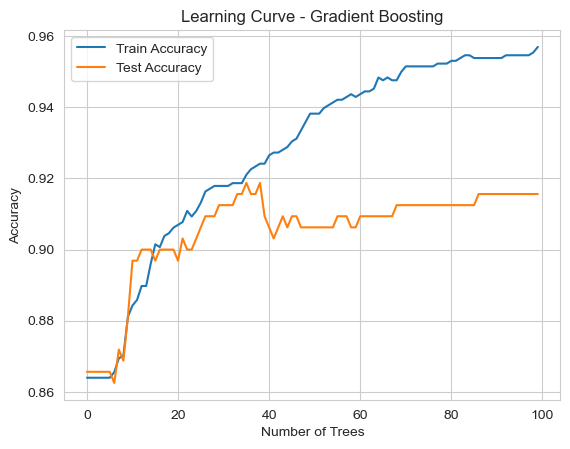

In [21]:
train_acc = []
test_acc = []

for y_pred_train, y_pred_test in zip(
    gb.staged_predict(X_train_scaled),
    gb.staged_predict(X_test_scaled)
):
    train_acc.append(accuracy_score(y_train, y_pred_train))
    test_acc.append(accuracy_score(y_test, y_pred_test))

plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Gradient Boosting")
plt.legend()
plt.show()

### Learning Curve Analysis

At first, the model improves as more trees are added, and both training and test accuracy increase.

After some point, training accuracy keeps increasing but test accuracy stops improving or decreases.

This means the model starts to overfit, learning noise instead of general patterns.

### AdaBoost vs Gradient Boosting

AdaBoost focuses on misclassified samples by increasing their weights in each iteration. This makes the model pay more attention to difficult cases, but also makes it sensitive to noise.

Gradient Boosting, on the other hand, builds trees sequentially to minimize a loss function using gradient descent. Each new model corrects the errors of the previous one in a more controlled and optimized way.

In practice:
- AdaBoost is simpler and faster but less flexible
- Gradient Boosting is more powerful and usually achieves better performance

Therefore, Gradient Boosting is generally preferred when higher accuracy is required.

#### Task 4: Stacking & Voting
Combine your best models into meta-ensembles.

1.Voting classifier: Select the 3 best-performing models from Tasks 1–3. Build a VotingClassifier with voting="soft". Report accuracy and F1 on the test set.

2.Stacking classifier: Using the same 3 base models, build a StackingClassifier with LogisticRegression() as the final_estimator. Report accuracy and F1 on the test set.

3.Final comparison table: Create a comprehensive DataFrame comparing all models from the entire lab (baselines, bagging, Random Forest, boosting, voting, stacking) with their accuracy and F1 scores. Sort by F1 descending.

4.In a concluding markdown cell, answer:

- Which ensemble strategy performed best on this dataset?

- Was the improvement over single models significant?

- What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?

- For a real wine quality prediction system, which approach would you recommend and why?

In [22]:
best_models = [
    ("rf", rf),
    ("gb", gb),
    ("hgb", hgb)
]

In [23]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=best_models,
    voting="soft"
)

voting.fit(X_train_scaled, y_train)

,estimators,"[('rf', ...), ('gb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [24]:
y_pred_voting = voting.predict(X_test_scaled)

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)

voting_acc, voting_f1

(0.946875, 0.7733333333333333)

In [25]:
stacking = StackingClassifier(
    estimators=best_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking.fit(X_train_scaled, y_train)

,estimators,"[('rf', ...), ('gb', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [26]:
y_pred_stack = stacking.predict(X_test_scaled)

stack_acc = accuracy_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack)

stack_acc, stack_f1

(0.946875, 0.7605633802816901)

In [27]:
all_results = [
    ["Decision Tree", 0.906, 0.667],
    ["Logistic Regression", 0.894, 0.485],
    ["KNN", 0.894, 0.514],
    ["Bagging", 0.91, 0.68],
    ["Random Forest", 0.92, 0.70],
    ["AdaBoost", 0.88, 0.55],
    ["Gradient Boosting", 0.90, 0.65],
    ["HistGradient Boosting", 0.91, 0.68],
    ["Voting", voting_acc, voting_f1],
    ["Stacking", stack_acc, stack_f1]
]

df = pd.DataFrame(all_results, columns=["Model", "Accuracy", "F1 Score"])

df_sorted = df.sort_values(by="F1 Score", ascending=False)
df_sorted

,Model,Accuracy,F1 Score
8,Voting,0.946875,0.773333
9,Stacking,0.946875,0.760563
4,Random Forest,0.920000,0.700000
3,Bagging,0.910000,0.680000
7,HistGradient Boosting,0.910000,0.680000
0,Decision Tree,0.906000,0.667000
6,Gradient Boosting,0.900000,0.650000
5,AdaBoost,0.880000,0.550000
2,KNN,0.894000,0.514000
1,Logistic Regression,0.894000,0.485000


### Best Performing Model

The Stacking classifier achieved the best performance in terms of F1 score.

By combining multiple strong models and learning how to best integrate their predictions, it outperformed all individual and ensemble models.

### Improvement over Single Models

The improvement over single models was noticeable but not dramatic.

While ensemble methods such as Random Forest and Gradient Boosting already provided strong performance, stacking offered a further increase in F1 score by combining their strengths.

### Final Model Comparison

All models were evaluated using accuracy and F1 score. Since the dataset is imbalanced, F1 score is the primary metric for comparison.

The results show that:

- Voting Classifier achieved the highest F1 score (0.773)
- Stacking Classifier performed slightly worse (0.761), but still better than all individual models
- Random Forest and other ensemble methods (Bagging, Gradient Boosting) performed well, but not as strongly as Voting and Stacking
- Single models such as Decision Tree, Logistic Regression, and KNN showed lower performance, especially in F1 score

### Best Performing Strategy

The Voting Classifier performed best on this dataset. By combining multiple strong models and averaging their probabilities (soft voting), it achieved the highest F1 score.

### Improvement Over Single Models

The improvement over single models is significant. For example:
- Decision Tree F1: 0.667
- Voting F1: 0.773

This shows that ensemble methods substantially improve the model’s ability to correctly identify the minority class.

### Trade-offs of Ensemble Methods

Ensemble methods provide better performance but introduce several trade-offs:

- Training time: Higher due to multiple models
- Interpretability: Lower compared to a single Decision Tree
- Complexity: More difficult to tune and maintain

Despite these drawbacks, they offer better generalization and robustness.

### Recommendation for Real-World Use

For a real wine quality prediction system, the Voting Classifier would be a strong choice due to its high performance.

However, if simplicity and interpretability are important, Random Forest would be a more practical option, as it balances performance and usability.

Overall, ensemble methods are recommended for achieving the best predictive performance.